Домашнее задание №4.
**Формулируем задачу в терминах ML.**

1. Загрузку и очистка данных - 5 баллов

2. Анализ данных - 5 баллов

3. Выбор 1-2 простых модели и 1 усложнённой (оптимизация гиперпараметров/AutoML/мультимодальность) - 10 баллов

4. Оценка метрик качества (не менее 2), оценка совокупной метрики качества, анализ результатов - 5 баллов


In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from pymystem3 import Mystem

Загрузка данных осуществлена с сайта banki.ru с помощью парсера. Парсер будет оптимизирован на этапе сборки приложения.

In [3]:
raw_dataset = pd.read_excel('mortgage_reviews_database_baseline.xlsx')

In [25]:
raw_dataset

,ID,Заголовок,Пользователь (API),Оценка,Дата создания (API),Количество комментариев,Учитывается в рейтинге,Статус отзыва,Текст отзыва (API),Название банка,...,Ответ банка (детально),Прозрачные условия,Вежливые сотрудники,Доступность и поддержка,"Удобство приложения, сайта",Ссылка на список,Ссылка на страницу,Дата выгрузки,Страница выгрузки,Ошибка
0,12729274,Отзыв,user-247923046216,5.0,2025-11-16 00:44:12,0,Нет,Не зачтено,Хотела бы оставить положительный отзыв о работ...,Норвик Банк,...,NaN,3.0,3.0,3.0,3.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN
1,12729235,Зачем мне переплачивать за свою жизнь по ипоте...,Амисс,1.0,2025-11-15 23:54:54,2,NaN,Проверяется,Зачем мне переплачивать за страхование своей ж...,Сбербанк,...,NaN,1.0,2.0,2.0,2.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN
2,12729222,Благодарность,user-900423400391,5.0,2025-11-15 23:45:39,1,NaN,Проверяется,"Благодарю сотрудника 70285569 Кирилла, за чут...",ВТБ,...,NaN,3.0,3.0,3.0,3.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN
3,12729128,Благодарность,user-402323399791,5.0,2025-11-15 22:07:33,1,NaN,Проверяется,"Табельный номер:70272841 оператор Максим,помог...",ВТБ,...,NaN,3.0,3.0,3.0,2.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN
4,12729127,Отказ по объекту недвижимости,user-314523281111,1.0,2025-11-15 22:05:11,0,NaN,Проверяется,"Одобрили ипотеку, и одобрили повышение суммы п...",Сбербанк,...,NaN,1.0,2.0,1.0,1.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19635,11376939,Военная ипотека. Жалоба,user-100515539209,2.0,2024-02-26 10:16:08,1,Да,Зачтено,"У меня проходит оформление военной ипотеки,где...",ВТБ,...,NaN,2.0,1.0,1.0,2.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-17 12:36:12,1000,NaN
19636,11376905,Банк не принимает страховой полис по ипотеке,user-955417212966,1.0,2024-02-26 09:49:30,2,Нет,Не зачтено,Переписка с банком ведётся с 1го февраля. На п...,Альфа-Банк,...,NaN,3.0,3.0,1.0,2.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-17 12:36:12,1000,NaN
19637,11376872,Быстрое получение ипотеки,user7736813,5.0,2024-02-26 09:24:48,0,Нет,Не зачтено,Здравствуйте! Как я могу вам помочь сегодня?\n...,Альфа-Банк,...,NaN,3.0,3.0,3.0,3.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-17 12:36:12,1000,NaN
19638,11376852,Качество,user-233017132994,5.0,2024-02-26 08:54:33,0,Нет,Не зачтено,"""Являюсь клиентом Альфа-Банка уже несколько ле...",Альфа-Банк,...,NaN,3.0,3.0,3.0,NaN,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-17 12:36:12,1000,NaN


18 текстовых столбцов
4 целочисленных
8 с плавающей точкой

In [5]:
raw_dataset.dtypes.value_counts()

object     18
float64     8
int64       4
Name: count, dtype: int64

Из перечня столбцов, не оценивая качество заполнения прчоих, данные отсуствуют в: <br>
   - Пользователь (API) - не критично для модели <br>
   - Оценка - что критично для модели <br>
   - Учитывается в рейтинге - важно для фильтрации датасета <br>
   - Текст отзыва (API) - отзыв с основной страницы <br>
   - Регион банка - может потребоваться для построения тепловой карты распределения оценок по банкам <br>
   - Ответ банка (API) - данные не критичны для основной части проекта и могут потребоваться для обучения модели отвечать по шаблонам банка <br>
   - ID сотрудника - не критично на текущем этапе разработки проекта <br>
   - Пользователь (страница) - требуется проверка наполнения <br>
   - Город пользователя - может потребоваться для составления тепловой карты и для модели <br>
   - Полный текст отзыва - текст отзыва с подстраницы отзыва, вероятно ошибки в работе парсера <br>
   - Комментарии - отсутствуют, столбец подлежит удалению. Вероятно общение идёт в блоке "ответ банка" <br>
   - Дата отзыва (страница) - большая часть данных присутствует, данные важны для проекта <br>
   - Рейтинг (страница) - оценка пользователя, содержит больше оценок, чем столбец "оценка" с основной страницы <br>
   - Ответ банка (детально) - опциональное поле для последующего развития проекта, мало данных. <br>

   - Ссылка на список, Ссылка на страницу, Дата выгрузки, Страница выгрузки, Ошибка - технические поля с URL страницами <br>

+ Столбцы "Прозрачные условия", "Вежливые сотрудники", "Доступность и поддержка", "Удобство приложения, сайта" - являются виджетами на сайте и могли быть внедрены в определенный момент времени. Что позволяет дать более глубокую оценку от пользователей по работе банка, но данные должны являться вспомогательными для проекта. <br>

In [6]:
raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19640 entries, 0 to 19639
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          19640 non-null  int64  
 1   Заголовок                   19640 non-null  object 
 2   Пользователь (API)          19638 non-null  object 
 3   Оценка                      18139 non-null  float64
 4   Дата создания (API)         19640 non-null  object 
 5   Количество комментариев     19640 non-null  int64  
 6   Учитывается в рейтинге      17566 non-null  object 
 7   Статус отзыва               19640 non-null  object 
 8   Текст отзыва (API)          19639 non-null  object 
 9   Название банка              19640 non-null  object 
 10  ID банка                    19640 non-null  int64  
 11  Регион банка                19558 non-null  object 
 12  Ответ банка (API)           19060 non-null  object 
 13  ID сотрудника               190

Датасет содержит 30 столбцов и 19640 строк

Смотрим на числовые статистики по сырому датасету:
- Средняя оценка по главной странице 3,4
- Средняя оценка по подстранице отзыва 3,5

- Средний рейтинг с основной страницы 3,4
- Средний рейтинг с подстраницы 3,6

Средний рейтинг по виджетам:
+ Прозрачные условия 2,3
+ Вежливые сотрудники 2,5
+ Доступность и поддержка 2,3
+ Удобство приложения, сайта 2,4

In [7]:
raw_dataset.describe()

,ID,Оценка,Количество комментариев,ID банка,ID сотрудника,Комментарии,Рейтинг (страница),Прозрачные условия,Вежливые сотрудники,Доступность и поддержка,"Удобство приложения, сайта",Страница выгрузки
count,1.964000e+04,18139.000000,19640.000000,1.964000e+04,1.906000e+04,0.0,19441.000000,17204.000000,17190.000000,17398.000000,16971.000000,19640.000000
mean,1.213429e+07,3.444732,1.443839,9.615721e+04,9.755335e+04,NaN,3.564374,2.267845,2.518965,2.266582,2.402216,408.570825
std,3.480176e+05,1.873131,2.526262,8.333181e+05,8.451129e+05,NaN,1.846497,0.918139,0.763473,0.926747,0.830491,251.294106
min,1.137682e+07,1.000000,0.000000,3.220000e+02,3.220000e+02,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.184835e+07,1.000000,0.000000,3.220000e+02,3.220000e+02,NaN,1.000000,1.000000,2.000000,1.000000,2.000000,197.000000
50%,1.215733e+07,5.000000,1.000000,3.270000e+02,3.270000e+02,NaN,5.000000,3.000000,3.000000,3.000000,3.000000,395.000000
75%,1.243107e+07,5.000000,2.000000,6.055000e+03,5.306000e+03,NaN,5.000000,3.000000,3.000000,3.000000,3.000000,594.000000
max,1.272927e+07,5.000000,73.000000,1.175295e+07,1.175295e+07,NaN,5.000000,3.000000,3.000000,3.000000,3.000000,1000.000000


Датасет включает в себя период с 26 февраля 2024 по 16 ноября 2025 года

In [8]:
# df['date_str'] = pd.to_datetime(df['date_str'])
raw_dataset['Дата создания (API)'] = pd.to_datetime(raw_dataset['Дата создания (API)'])
raw_dataset['Дата отзыва (страница)'] = pd.to_datetime(raw_dataset['Дата отзыва (страница)'])

print(raw_dataset['Дата создания (API)'].min())
print(raw_dataset['Дата создания (API)'].max())

print(raw_dataset['Дата отзыва (страница)'].min())
print(raw_dataset['Дата отзыва (страница)'].max())

2024-02-26 07:43:56
2025-11-16 00:44:12
2024-02-26 07:43:00
2025-11-16 00:44:00


C:\Users\Игорь\AppData\Local\Temp\ipykernel_21044\3773916325.py:3: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  raw_dataset['Дата отзыва (страница)'] = pd.to_datetime(raw_dataset['Дата отзыва (страница)'])


Смотрим статистики по клиентам:

Количество пользователей в городах

In [50]:
# количество уникальных пользователей и городов (по пользователям только верхнеуровневая оценка, т.к. даже со вторым критерием нет достоверной оценки уникальности)
raw_dataset[['Пользователь (API)', 'Город пользователя']].nunique()

Пользователь (API)    18589
Город пользователя     1400
dtype: int64

In [16]:
# смотрим уникальные города клиентов и количество пользователей по городам
user_city_stats = raw_dataset['Город пользователя'].value_counts()
user_city_stats

Город пользователя
Москва                                 3899
Санкт-Петербург                        1627
Ростов-на-Дону (Ростовская область)     534
Краснодар (Краснодарский край)          513
Якутск (Республика Саха (Якутия))       451
                                       ... 
Михайлов (Ростовская область)             1
Западный (Челябинская область)            1
Шадринск (Курганская область)             1
Почеп                                     1
Васильево (Республика Татарстан)          1
Name: count, Length: 1400, dtype: int64

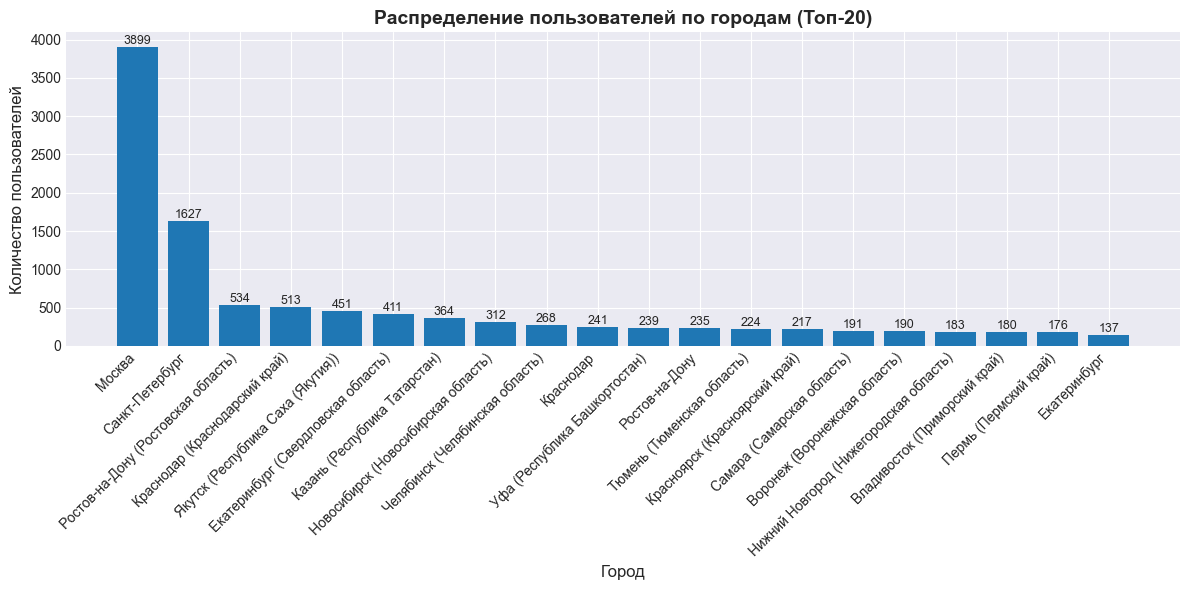

In [17]:
# строим график распределения пользователей по городам
# Настройка стиля
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-darkgrid')

# Строим график
bars = plt.bar(user_city_stats.index[:20], user_city_stats.values[:20])

# Настройка внешнего вида
plt.title('Распределение пользователей по городам (Топ-20)', fontsize=14, fontweight='bold')
plt.xlabel('Город', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.show()

Средняя оценка пользователя по городам

In [30]:
# Расширенная статистика по городам
city_rating_stats = raw_dataset.groupby('Город пользователя')['Рейтинг (страница)'].agg([
    ('Количество_оценок', 'count'),      # сколько всего оценок
    ('Средняя_оценка', 'mean'),          # средняя оценка
    ('Медианная_оценка', 'median'),      # медиана
    ('Стандартное_отклонение', 'std'),   # разброс оценок
]).round(2)

# Сортируем по средней оценке
city_rating_stats = city_rating_stats.sort_values('Количество_оценок', ascending=False)

print("Статистика оценок по городам:")
print(city_rating_stats.head(15))

Статистика оценок по городам:
                                     Количество_оценок  Средняя_оценка  \
Город пользователя                                                       
Москва                                            3897            3.24   
Санкт-Петербург                                   1627            3.12   
Ростов-на-Дону (Ростовская область)                534            4.34   
Краснодар (Краснодарский край)                     513            3.35   
Якутск (Республика Саха (Якутия))                  451            3.11   
Екатеринбург (Свердловская область)                411            3.06   
Казань (Республика Татарстан)                      364            3.09   
Новосибирск (Новосибирская область)                312            3.00   
Челябинск (Челябинская область)                    268            3.39   
Краснодар                                          241            4.90   
Уфа (Республика Башкортостан)                      239            2.91   
Ростов-н

In [38]:
# top и bottom, покажут только часть городов.
mean_rating_by_city = raw_dataset.groupby('Город пользователя')['Рейтинг (страница)'].mean()
mean_rating_by_city = mean_rating_by_city.sort_values(ascending=False)

print("Средняя оценка пользователя по городам:")
print(mean_rating_by_city.head(10))  # Топ-10 городов с лучшими оценками
print("\n" + "="*50 + "\n")
print("Худшие средние оценки:")
print(mean_rating_by_city.tail(10))  # Топ-10 городов с худшими оценками

Средняя оценка пользователя по городам:
Город пользователя
Абаза (Республика Хакасия)           5.0
Яя                                   5.0
Абалак (Тюменская область)           5.0
Яшкино (Кемеровская область)         5.0
Абага (Амгинский р-н)                5.0
Агинское                             5.0
Адамовка                             5.0
Абадзехская (Республика Адыгея)      5.0
Языково (Республика Башкортостан)    5.0
Ядрин (Чувашская Республика)         5.0
Name: Рейтинг (страница), dtype: float64


Худшие средние оценки:
Город пользователя
Юрино (Республика Марий Эл)                            1.0
Энем (Республика Адыгея)                               1.0
Алексеевка (Алексеевский го) (Белгородская область)    1.0
Шимановск (Амурская область)                           1.0
Барда (Пермский край)                                  1.0
Абинск (Краснодарский край)                            1.0
Шипуново (Алтайский край)                              1.0
Полевской                        

Средняя динамика оценки по месяцам

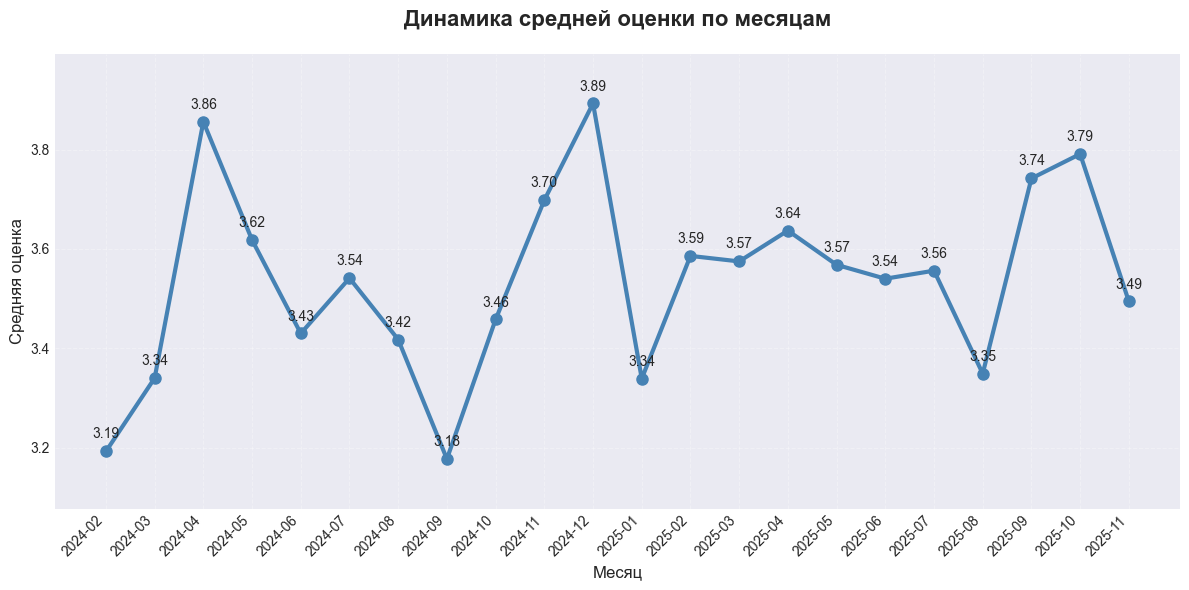

In [45]:
# Создаем столбец с месяцем для графика
raw_dataset['Month'] = raw_dataset['Дата отзыва (страница)'].dt.to_period('M')

# Группируем по месяцам и считаем среднюю оценку
monthly_ratings = raw_dataset.groupby('Month')['Рейтинг (страница)'].mean()

# Преобразуем месяц в строку для оси графика
monthly_ratings.index = monthly_ratings.index.astype(str)

# Строим график
plt.figure(figsize=(12, 6))

plt.plot(monthly_ratings.index, monthly_ratings.values,
         marker='o', markersize=8, linewidth=3, color='steelblue')

plt.title('Динамика средней оценки по месяцам', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Средняя оценка', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim([monthly_ratings.min() - 0.1, monthly_ratings.max() + 0.1])

# Добавляем сетку
plt.grid(True, alpha=0.3, linestyle='--')

# Добавляем значения точек
for x, y in zip(monthly_ratings.index, monthly_ratings.values):
    plt.text(x, y + 0.02, f'{y:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Теперь рассмотри статистики по банку

Количество уникальных банков

In [75]:
raw_dataset['Название банка'].nunique()

88

Количество уникальных городов по банкам (это город регистрации головного филиала)

In [66]:
# Количество и список уникальных городов
unique_cities_count = raw_dataset['Регион банка'].nunique()
unique_cities_list = raw_dataset['Регион банка'].unique()

print(f"Количество уникальных городов банка: {unique_cities_count}")
print(f"\nСписок уникальных городов ({unique_cities_list})")

Количество уникальных городов банка: 22

Список уникальных городов (['Киров' 'Москва' 'Санкт-Петербург' 'Набережные Челны' 'Кострома'
 'Благовещенск' 'Новосибирск' 'Екатеринбург' 'Казань' nan 'Владивосток'
 'Краснодар' 'Вологда' 'Ростов-на-Дону' 'Сургут' 'Самара' 'Барнаул'
 'Симферополь' 'Горно-Алтайск' 'Оренбург' 'Омск' 'Array' 'Магнитогорск'])


Количество оценок по банкам

In [76]:
# смотрим уникальные города клиентов и количество пользователей по городам
bank_stats = raw_dataset['Название банка'].value_counts()
bank_stats

Название банка
Сбербанк             4968
ВТБ                  2864
Альфа-Банк           2810
Банк ДОМ.РФ          2089
Совкомбанк           1989
                     ... 
Банк «ПСКБ»             1
Траст                   1
Интерпрогрессбанк       1
Кредит Урал Банк        1
РУСНАРБАНК              1
Name: count, Length: 88, dtype: int64

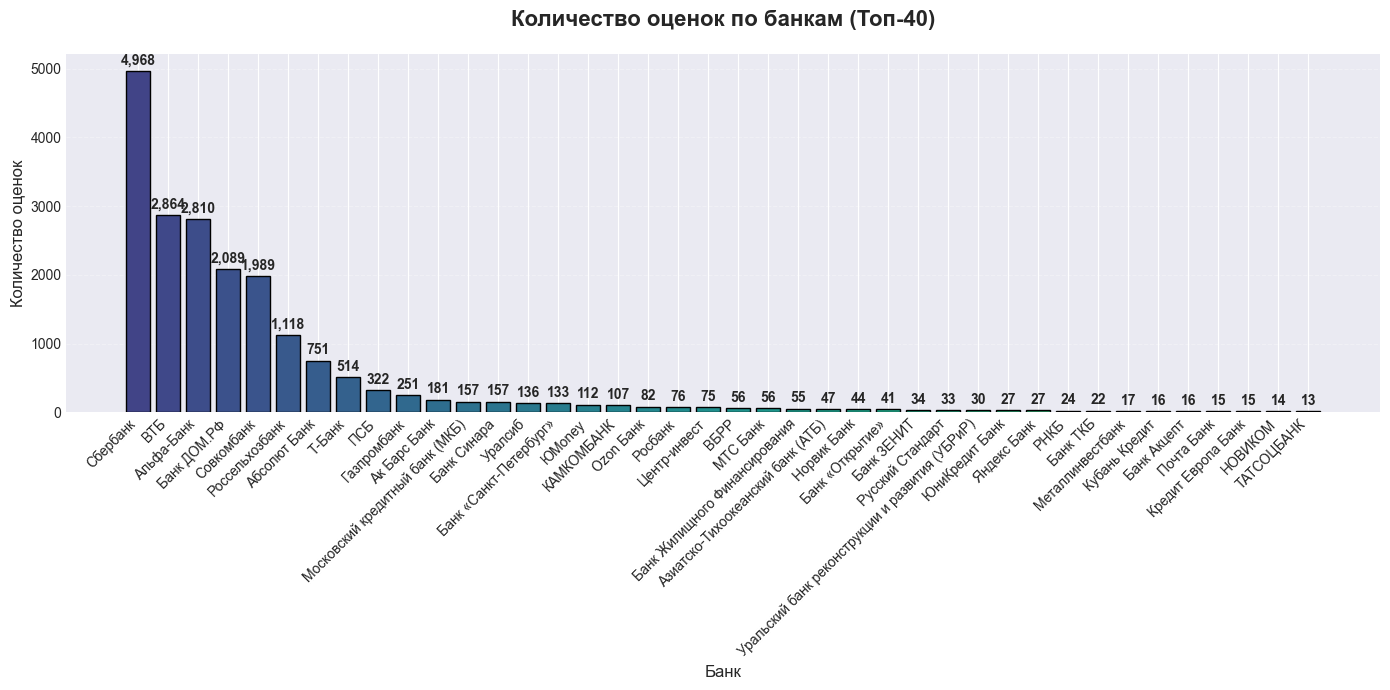

In [117]:
# сделаем график с накопительным количеством оценок банков
plt.figure(figsize=(14, 7))

# Берем топ-40 банков для лучшей визуализации (методом подбора с сохранением читаемости графика)
top_n = 40
top_banks = bank_stats.head(top_n)

# Создаем столбцы с градиентом цвета
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_banks)))

bars = plt.bar(top_banks.index, top_banks.values, color=colors, edgecolor='black', linewidth=1)

# Настройки графика
plt.title(f'Количество оценок по банкам (Топ-{top_n})',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Банк', fontsize=12)
plt.ylabel('Количество оценок', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Добавляем значения на столбцы
for bar, count in zip(bars, top_banks.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max(top_banks.values)*0.01,
             f'{int(count):,}',  # Форматирование с разделителями тысяч
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Сетка
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Средняя оценка банка в датасете и динамика средней помесячно

In [74]:
mean_rating_by_bank = raw_dataset.groupby('Название банка')['Рейтинг (страница)'].mean().sort_values(ascending=False)
mean_rating_by_bank

Название банка
SBI Банк          5.0
SEB               5.0
АвтоКредитБанк    5.0
Авангард          5.0
БМВ Банк          5.0
                 ... 
Тимер Банк        1.0
Траст             1.0
Энергобанк        1.0
Банк «ПСКБ»       NaN
Солид Банк        NaN
Name: Рейтинг (страница), Length: 88, dtype: float64

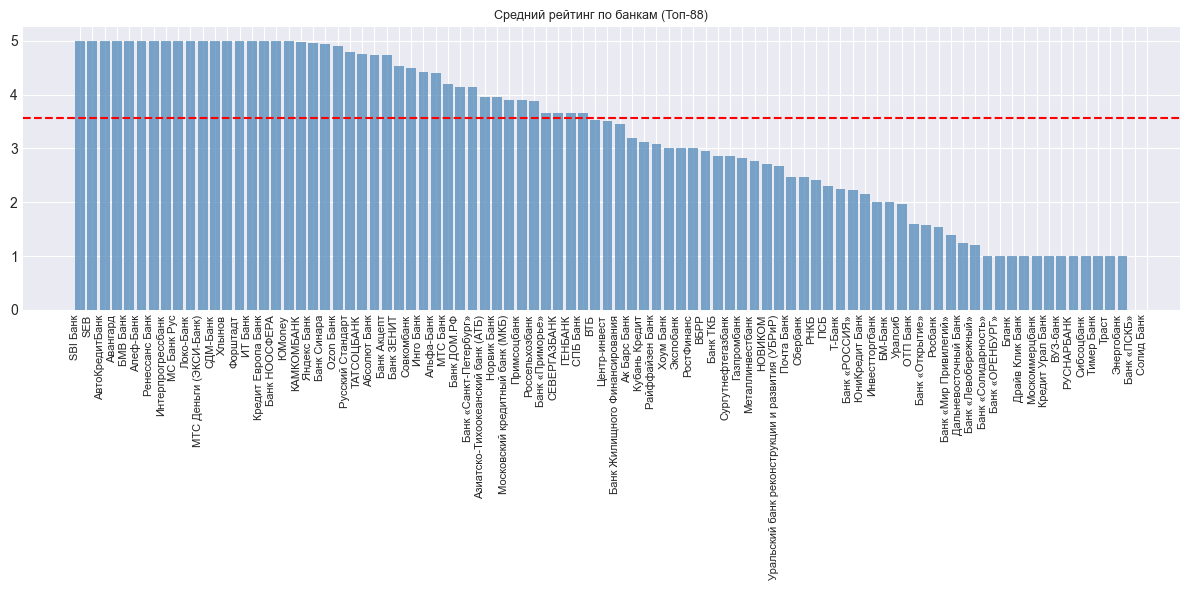

In [119]:
# График сравнения средней оценки тотал со средней оценкой банка
plt.figure(figsize=(12, 6))

# включаем на полотно все банки
top_n = 88
top_banks = mean_rating_by_bank.head(top_n)

plt.bar(top_banks.index, top_banks.values, alpha=0.7, color='steelblue')
plt.axhline(y=overall_mean, color='red', linestyle='--', label=f'Среднее: {overall_mean:.2f}')

plt.title(f'Средний рейтинг по банкам (Топ-{top_n})', fontsize=9)
plt.xticks(rotation=90, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

Динамика средней оценки помесячно ТОП3 банков

Топ-3 банков по количеству отзывов:
1. Сбербанк (4968 отзывов)
2. ВТБ (2864 отзывов)
3. Альфа-Банк (2810 отзывов)


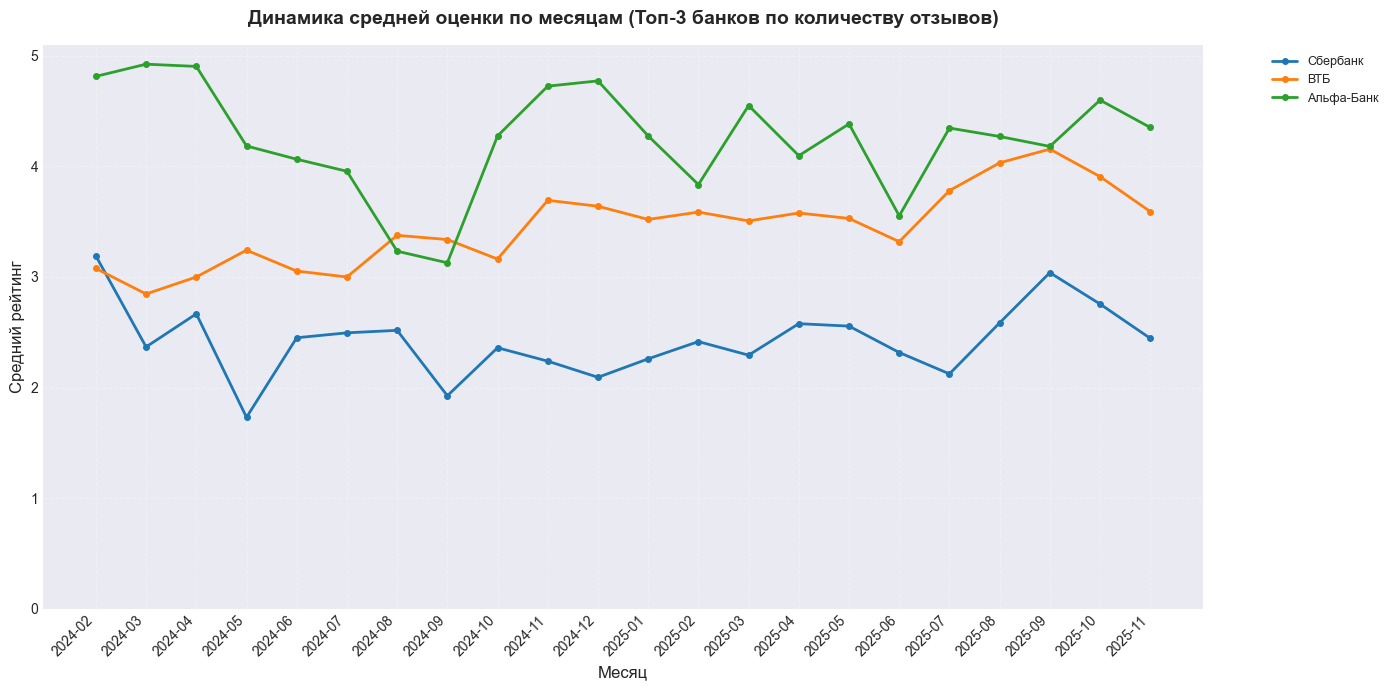

In [114]:
# месяцы для оси
raw_dataset['month_str'] = raw_dataset['Month'].dt.strftime('%Y-%m')  # Преобразуем в строку формата "2024-01"

# топ-3 банков по количеству отзывов
top_3_banks = raw_dataset['Название банка'].value_counts().head(3).index.tolist()

print(f"Топ-3 банков по количеству отзывов:")
for i, bank in enumerate(top_3_banks, 1):
    count = raw_dataset['Название банка'].value_counts()[bank]
    print(f"{i}. {bank} ({count} отзывов)")

# Строим график
plt.figure(figsize=(14, 7))

# Для каждого банка строим свою линию
for bank in top_3_banks:
    # Фильтруем данные по банку
    bank_data = raw_dataset[raw_dataset['Название банка'] == bank]
    # Группируем по месяцам и считаем среднюю оценку
    monthly_ratings = bank_data.groupby('month_str')['Рейтинг (страница)'].mean()
    # Сортируем по дате (месяцам)
    monthly_ratings = monthly_ratings.sort_index()
    # Строим линию
    plt.plot(monthly_ratings.index, monthly_ratings.values,
             marker='o', linewidth=2, markersize=4, label=bank)

# Настройки графика
plt.title('Динамика средней оценки по месяцам (Топ-3 банков по количеству отзывов)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Средний рейтинг', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)  # Легенда справа
plt.grid(True, alpha=0.3, linestyle='--')

# Устанавливаем границы оси Y
plt.ylim(0, 5.1)

plt.tight_layout()
plt.show()

Работаем со статусами и текстами отзывов

In [121]:
raw_dataset[['Заголовок', 'Текст отзыва (API)', 'Полный текст отзыва', 'Учитывается в рейтинге', 'Статус отзыва']]

,Заголовок,Текст отзыва (API),Полный текст отзыва,Учитывается в рейтинге,Статус отзыва
0,Отзыв,Хотела бы оставить положительный отзыв о работ...,\nХотела бы оставить положительный отзыв о раб...,Нет,Не зачтено
1,Зачем мне переплачивать за свою жизнь по ипоте...,Зачем мне переплачивать за страхование своей ж...,\nЗачем мне переплачивать за страхование своей...,NaN,Проверяется
2,Благодарность,"Благодарю сотрудника 70285569 Кирилла, за чут...",NaN,NaN,Проверяется
3,Благодарность,"Табельный номер:70272841 оператор Максим,помог...","\nТабельный номер:70272841 оператор Максим,пом...",NaN,Проверяется
4,Отказ по объекту недвижимости,"Одобрили ипотеку, и одобрили повышение суммы п...","\nОдобрили ипотеку, и одобрили повышение суммы...",NaN,Проверяется
...,...,...,...,...,...
19635,Военная ипотека. Жалоба,"У меня проходит оформление военной ипотеки,где...","\nУ меня проходит оформление военной ипотеки,г...",Да,Зачтено
19636,Банк не принимает страховой полис по ипотеке,Переписка с банком ведётся с 1го февраля. На п...,\nПереписка с банком ведётся с 1го февраля. На...,Нет,Не зачтено
19637,Быстрое получение ипотеки,Здравствуйте! Как я могу вам помочь сегодня?\n...,\nЗдравствуйте! Как я могу вам помочь сегодня?...,Нет,Не зачтено
19638,Качество,"""Являюсь клиентом Альфа-Банка уже несколько ле...",\n\t\t\t\tСпасибо за отзыв. Принимаем его без ...,Нет,Не зачтено


Для последующей работы мы оставим заголовок (тема) и колонку Текст отзыва (API) так как она содержит меньше нерелевантных символом

Проверяем статистики по учёту в рейтинге и статусу отзыва

In [126]:
raw_dataset['Учитывается в рейтинге'].value_counts()
# na = 2074 пропущенных

Учитывается в рейтинге
Нет    11832
Да      5734
Name: count, dtype: int64

In [124]:
raw_dataset['Статус отзыва'].value_counts()

Статус отзыва
Не зачтено         11719
Зачтено             5672
Проверяется         2052
Ошибка парсинга      197
Name: count, dtype: int64

In [134]:
raw_dataset
# смотрим датасет и статистики для сборки столбцов

,ID,Заголовок,Пользователь (API),Оценка,Дата создания (API),Количество комментариев,Учитывается в рейтинге,Статус отзыва,Текст отзыва (API),Название банка,...,Вежливые сотрудники,Доступность и поддержка,"Удобство приложения, сайта",Ссылка на список,Ссылка на страницу,Дата выгрузки,Страница выгрузки,Ошибка,Month,Месяц_строка
0,12729274,Отзыв,user-247923046216,5.0,2025-11-16 00:44:12,0,Нет,Не зачтено,Хотела бы оставить положительный отзыв о работ...,Норвик Банк,...,3.0,3.0,3.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN,2025-11,2025-11
1,12729235,Зачем мне переплачивать за свою жизнь по ипоте...,Амисс,1.0,2025-11-15 23:54:54,2,NaN,Проверяется,Зачем мне переплачивать за страхование своей ж...,Сбербанк,...,2.0,2.0,2.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN,2025-11,2025-11
2,12729222,Благодарность,user-900423400391,5.0,2025-11-15 23:45:39,1,NaN,Проверяется,"Благодарю сотрудника 70285569 Кирилла, за чут...",ВТБ,...,3.0,3.0,3.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN,2025-11,2025-11
3,12729128,Благодарность,user-402323399791,5.0,2025-11-15 22:07:33,1,NaN,Проверяется,"Табельный номер:70272841 оператор Максим,помог...",ВТБ,...,3.0,3.0,2.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN,2025-11,2025-11
4,12729127,Отказ по объекту недвижимости,user-314523281111,1.0,2025-11-15 22:05:11,0,NaN,Проверяется,"Одобрили ипотеку, и одобрили повышение суммы п...",Сбербанк,...,2.0,1.0,1.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-16 05:12:59,1,NaN,2025-11,2025-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19635,11376939,Военная ипотека. Жалоба,user-100515539209,2.0,2024-02-26 10:16:08,1,Да,Зачтено,"У меня проходит оформление военной ипотеки,где...",ВТБ,...,1.0,1.0,2.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-17 12:36:12,1000,NaN,2024-02,2024-02
19636,11376905,Банк не принимает страховой полис по ипотеке,user-955417212966,1.0,2024-02-26 09:49:30,2,Нет,Не зачтено,Переписка с банком ведётся с 1го февраля. На п...,Альфа-Банк,...,3.0,1.0,2.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-17 12:36:12,1000,NaN,2024-02,2024-02
19637,11376872,Быстрое получение ипотеки,user7736813,5.0,2024-02-26 09:24:48,0,Нет,Не зачтено,Здравствуйте! Как я могу вам помочь сегодня?\n...,Альфа-Банк,...,3.0,3.0,3.0,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-17 12:36:12,1000,NaN,2024-02,2024-02
19638,11376852,Качество,user-233017132994,5.0,2024-02-26 08:54:33,0,Нет,Не зачтено,"""Являюсь клиентом Альфа-Банка уже несколько ле...",Альфа-Банк,...,3.0,3.0,NaN,https://www.banki.ru/services/responses/list/p...,https://www.banki.ru/services/responses/bank/r...,2025-11-17 12:36:12,1000,NaN,2024-02,2024-02


Для последующей работы с текстом и созданием Baseline моделей, нам потребуется отфильтровать и отчистить датасет

In [132]:
baseline_dataset = raw_dataset[[
    'Дата создания (API)',
    'Заголовок',
    'Текст отзыва (API)',
    'Город пользователя',

    'ID банка',
    'Название банка',
    'ID сотрудника',
    'Ответ банка (API)',
    'Количество комментариев',

    'Учитывается в рейтинге',
    'Статус отзыва',

    'Рейтинг (страница)', # оценка пользователя
    'Прозрачные условия',
    'Вежливые сотрудники',
    'Доступность и поддержка',
    'Удобство приложения, сайта',
]]

Собрали датасет, начинаем последовательную фильтрацию и отчистку

In [140]:
baseline_dataset = baseline_dataset[baseline_dataset['Учитывается в рейтинге'] == 'Да']

In [144]:
baseline_dataset = baseline_dataset[baseline_dataset['Статус отзыва'] == 'Зачтено']

In [157]:
baseline_dataset['ID сотрудника'] = baseline_dataset['ID сотрудника'].fillna(0)

C:\Users\Игорь\AppData\Local\Temp\ipykernel_21044\2272417152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline_dataset['ID сотрудника'] = baseline_dataset['ID сотрудника'].fillna(0)


In [159]:
baseline_dataset['ID сотрудника'] = baseline_dataset['ID сотрудника'].astype(int)

C:\Users\Игорь\AppData\Local\Temp\ipykernel_21044\4120071570.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline_dataset['ID сотрудника'] = baseline_dataset['ID сотрудника'].astype(int)


In [163]:
baseline_dataset['Ответ банка (API)'] = baseline_dataset['Ответ банка (API)'].fillna('Нет ответа')

C:\Users\Игорь\AppData\Local\Temp\ipykernel_21044\4287894329.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline_dataset['Ответ банка (API)'] = baseline_dataset['Ответ банка (API)'].fillna('Нет ответа')


Работаем с пропусками в столбцах с оценкой

In [ ]:
baseline_dataset['Прозрачные условия'] = baseline_dataset.groupby('Название банка')['Прозрачные условия'].transform(lambda x: x.fillna(x.mean()).round(2))
baseline_dataset['Вежливые сотрудники'] = baseline_dataset.groupby('Название банка')['Вежливые сотрудники'].transform(lambda x: x.fillna(x.mean()).round(2))
baseline_dataset['Доступность и поддержка'] = baseline_dataset.groupby('Название банка')['Доступность и поддержка'].transform(lambda x: x.fillna(x.mean()).round(2))
baseline_dataset['Удобство приложения, сайта'] = baseline_dataset.groupby('Название банка')['Удобство приложения, сайта'].transform(lambda x: x.fillna(x.mean()).round(2))

In [179]:
baseline_dataset = baseline_dataset.dropna()

In [181]:
baseline_dataset

,Дата создания (API),Заголовок,Текст отзыва (API),Город пользователя,ID банка,Название банка,ID сотрудника,Ответ банка (API),Количество комментариев,Учитывается в рейтинге,Статус отзыва,Рейтинг (страница),Прозрачные условия,Вежливые сотрудники,Доступность и поддержка,"Удобство приложения, сайта"
92,2025-11-14 07:25:46,Открытие текущего счета,14.11.2025 пришли в банк Дом РФ-одобрили ипоте...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,Зачтено,5,3.00,3.00,3.00,3.00
124,2025-11-13 13:07:32,Идентификация,13.11.25 обратилась в офис банка в городк Тюме...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,Зачтено,5,3.00,3.00,3.00,3.00
125,2025-11-13 12:59:38,Консультация,Обратился в отделение банка 13 ноября этого го...,Пермь (Пермский край),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,Зачтено,5,3.00,3.00,3.00,3.00
130,2025-11-13 11:49:12,Справка,Сегодня в 16:30 пришла в банк Дом Рф в городе ...,Иркутск (Иркутская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,Зачтено,5,3.00,3.00,3.00,3.00
132,2025-11-13 11:32:24,Оформление нового счета,13.11.2025 года посетила офис Банка Дом Рф в г...,Ижевск (Удмуртская Республика),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,1,Да,Зачтено,5,3.00,3.00,3.00,3.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19625,2024-02-26 14:05:16,Оперативно решили важный вопрос,Выражаю огромную благодарность Ф-ой Галине (гл...,Тула (Тульская область),325,Альфа-Банк,325,"Приветствуем!_x000D_\n_x000D_\nСпасибо, нам оч...",2,Да,Зачтено,5,3.00,3.00,3.00,3.00
19629,2024-02-26 12:30:35,Предоставление справки,11 января 2024 г. заказала справку о выплаченн...,Волгоград (Волгоградская область),2237,Банк ДОМ.РФ,2237,Добрый день! _x000D_\n_x000D_\nВ результате ра...,3,Да,Зачтено,1,2.63,2.72,1.00,2.62
19631,2024-02-26 12:05:18,"Подписал ипотеку и 20 дней тишина, банк деньги...",При покупки квартиры решили взять ипотеку в ба...,Абабково (Нижегородская область),2237,Банк ДОМ.РФ,2237,Добрый день! _x000D_\n_x000D_\nВ результате ра...,2,Да,Зачтено,1,2.63,2.72,2.55,2.62
19633,2024-02-26 11:28:08,Благодарность ипотечному менеджеру,Выражаю благодарность М-ой Елене А. (клиентски...,Серпухов (Москва и область),322,Сбербанк,322,"Здравствуйте!_x000D_\n_x000D_\nСпасибо, что от...",0,Да,Зачтено,5,3.00,3.00,3.00,3.00


In [187]:
baseline_dataset.to_csv('D:/pars/baseline_dataset.csv')

Количественные показатели отчищены, подготавливаем текстовые столбцы, создаём векторное представление текстов.

ВАЖНО! Т.к. это бейзлайн, буду использовать простые модели.

In [185]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Игорь\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [193]:
# Инициализируем лемматизатор - будет использован в более сложных моделях
mystem = Mystem()

# Русские стоп-слова
russian_stopwords = stopwords.words('russian')
# Добавим дополнительные стоп-слова
additional_stopwords = ['это', 'как', 'так', 'и', 'в', 'над', 'к', 'до', 'не', 'на', 'но', 'за', 'то', 'с',
                       'ли', 'а', 'во', 'от', 'со', 'для', 'о', 'же', 'ну', 'вы', 'бы', 'что', 'кто',
                       'он', 'она', 'год', 'весь', 'свой', 'банк', 'кредит', 'карта', 'счёт', 'отзыв']
russian_stopwords.extend(additional_stopwords)

Installing mystem to C:\Users\Игорь/.local/bin\mystem.exe from http://download.cdn.yandex.net/mystem/mystem-3.1-win-64bit.zip


In [202]:
def clean_russian_text(text):
    """
    Очистка и подготовка русского текста
    """
    if pd.isna(text):
        return ""

    # Приводим к строке
    text = str(text)
    # Приводим к нижнему регистру
    text = text.lower()
    # Удаляем HTML-теги
    text = re.sub(r'<[^>]+>', '', text)
    # Удаляем URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Удаляем email
    text = re.sub(r'\S+@\S+', '', text)
    # Удаляем числа
    text = re.sub(r'\d+', '', text)
    # Удаляем пунктуацию и специальные символы
    text = re.sub(r'[^\w\s]', ' ', text)
    # Удаляем лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def lemmatize_text(text):
    """
    Лемматизация русского текста
    """
    if not text:
        return ""

    # Лемматизируем
    lemmas = mystem.lemmatize(text)
    # Объединяем обратно
    lemmatized_text = ''.join(lemmas).strip()
    # Удаляем стоп-слова
    words = lemmatized_text.split()
    filtered_words = [word for word in words if word not in russian_stopwords and len(word) > 2]

    return ' '.join(filtered_words)

def vectorize_with_tfidf(texts, max_features=5000, ngram_range=(1, 2)):
    """
    Векторизация текстов с помощью TF-IDF
    Returns:
    --------
    tuple: (векторизованные данные, векторный преобразователь)
    """
    # Инициализируем TF-IDF векторизатор
    tfidf = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=2,  # слово должно встречаться минимум в 2 документах
        max_df=0.8,  # слово должно встречаться максимум в 80% документов
        stop_words=russian_stopwords
    )

    # Преобразуем тексты
    vectors = tfidf.fit_transform(texts)

    return vectors, tfidf

# # Основной пайплайн - оставляем на эксперименты с улучшением качества работы модели на домашнем задании 5-го урока.
# def process_dataframe(df):
#     """
#     пайплайн обработки и векторизации текстов
#     """
#     # 1. Создаем копию датафрейма чтобы не изменять оригинал
#     df_processed = df.copy()
#
#     print("Начало обработки текстов...")
#
#     # 2. Очищаем тексты отзывов
#     print("Шаг 1: Очистка текстов отзывов...")
#     df_processed['Текст отзыва отчищенный'] = df_processed['Текст отзыва (API)'].apply(clean_russian_text)
#
#     # 3. Лемматизируем тексты отзывов
#     print("Шаг 2: Лемматизация текстов отзывов...")
#     df_processed['Текст отзыва отчищенный'] = df_processed['Текст отзыва отчищенный'].apply(lemmatize_text)
#
#     # 4. Очищаем заголовки (более простая очистка)
#     print("Шаг 3: Очистка заголовков...")
#     df_processed['Заголовок_очищенный'] = df_processed['Заголовок'].apply(
#         lambda x: clean_russian_text(x) if pd.notna(x) else ""
#     )
#
#     # 5. Векторизуем заголовки
#     print("Шаг 4: Векторизация заголовков...")
#     title_texts = df_processed['Заголовок_очищенный'].fillna('').tolist()
#     title_vectors, title_tfidf = vectorize_with_tfidf(
#         title_texts,
#         max_features=2000,  # Меньше фич для заголовков
#         ngram_range=(1, 2)
#     )
#
#     # 6. Векторизуем тексты отзывов
#     print("Шаг 5: Векторизация текстов отзывов...")
#     review_texts = df_processed['Текст отзыва отчищенный'].fillna('').tolist()
#     review_vectors, review_tfidf = vectorize_with_tfidf(
#         review_texts,
#         max_features=10000,  # Больше фич для полных текстов
#         ngram_range=(1, 3)   # Более длинные n-граммы
#     )
#
#     # 7. Преобразуем векторы в списки для сохранения в датафрейме
#     print("Шаг 6: Сохранение векторов...")
#
#     # Для заголовков сохраняем только наиболее важные признаки
#     title_vectors_dense = title_vectors.toarray()
#     # Сохраняем как список
#     df_processed['Заголовок_TFIDF'] = list(title_vectors_dense)
#
#     # Для текстов отзывов
#     review_vectors_dense = review_vectors.toarray()
#     df_processed['Текст отзыва отчищенный_TFIDF'] = list(review_vectors_dense)
#
#     print(f"Обработка завершена!")
#     print(f"Обработано {len(df_processed)} строк")
#     print(f"Размерность векторов заголовков: {title_vectors.shape[1]}")
#     print(f"Размерность векторов отзывов: {review_vectors.shape[1]}")
#
#     # Возвращаем обработанный датафрейм и векторизаторы
#     return df_processed, title_tfidf, review_tfidf


# Упрощенный вариант (без лемматизации)
def process_dataframe_simple(df):
    """
    Упрощенный вариант для быстрой обработки
    """
    df_processed = df.copy()

    # Простая очистка текста
    def simple_clean(text):
        if pd.isna(text):
            return ""
        text = str(text).lower()
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    # Очистка
    df_processed['Текст отзыва отчищенный'] = df_processed['Текст отзыва (API)'].apply(simple_clean)
    df_processed['Заголовок_очищенный'] = df_processed['Заголовок'].apply(simple_clean)

    # TF-IDF векторизация
    tfidf_title = TfidfVectorizer(max_features=1000, stop_words=russian_stopwords)
    tfidf_review = TfidfVectorizer(max_features=5000, stop_words=russian_stopwords)

    title_vectors = tfidf_title.fit_transform(df_processed['Заголовок_очищенный'])
    review_vectors = tfidf_review.fit_transform(df_processed['Текст отзыва отчищенный'])

    # Сохраняем векторы
    df_processed['Заголовок_TFIDF'] = [title_vectors[i].toarray().flatten() for i in range(len(df_processed))]
    df_processed['Текст отзыва отчищенный_TFIDF'] = [review_vectors[i].toarray().flatten() for i in range(len(df_processed))]

    return df_processed, tfidf_title, tfidf_review


In [203]:
# Пример с тестовыми данными
test_data = {
    'Заголовок': ['Отличный банк!', 'Ужасное обслуживание', 'Нормальный сервис'],
    'Текст отзыва (API)': [
        'Банк очень хороший, быстро отвечают на вопросы. Рекомендую всем!',
        'Ужасный сервис, долго ждал ответа от поддержки. Не рекомендую.',
        'Всё нормально, но есть мелкие недочёты в работе приложения.'
    ]
}

df_test = pd.DataFrame(test_data)

print("Тест обработки данных:")
print("Исходные данные:")
print(df_test)

# Обработка
df_processed, title_tfidf, review_tfidf = process_dataframe_simple(df_test)

print("\nОбработанные данные:")
print(df_processed[['Заголовок', 'Текст отзыва отчищенный']])

print(f"\nРазмерность TF-IDF векторов заголовков: {len(df_processed['Заголовок_TFIDF'].iloc[0])}")
print(f"Размерность TF-IDF векторов отзывов: {len(df_processed['Текст отзыва отчищенный_TFIDF'].iloc[0])}")

# Пример доступа к TF-IDF признакам
print(f"\nПример TF-IDF признаков для заголовков (первые 10):")
feature_names = title_tfidf.get_feature_names_out()
print(feature_names[:10])

Тест обработки данных:
Исходные данные:
              Заголовок                                 Текст отзыва (API)
0        Отличный банк!  Банк очень хороший, быстро отвечают на вопросы...
1  Ужасное обслуживание  Ужасный сервис, долго ждал ответа от поддержки...
2     Нормальный сервис  Всё нормально, но есть мелкие недочёты в работ...

Обработанные данные:
              Заголовок                            Текст отзыва отчищенный
0        Отличный банк!  банк очень хороший быстро отвечают на вопросы ...
1  Ужасное обслуживание  ужасный сервис долго ждал ответа от поддержки ...
2     Нормальный сервис  всё нормально но есть мелкие недочёты в работе...

Размерность TF-IDF векторов заголовков: 5
Размерность TF-IDF векторов отзывов: 19

Пример TF-IDF признаков для заголовков (первые 10):
['нормальный' 'обслуживание' 'отличный' 'сервис' 'ужасное']


In [204]:
# проверка
required_columns = ['Заголовок', 'Текст отзыва (API)']

if all(col in baseline_dataset.columns for col in required_columns):
    print(f"Найдены все необходимые столбцы в baseline_dataset")
    print(f"Размер датафрейма: {baseline_dataset.shape}")

    # обработка
    baseline_processed, title_tfidf, review_tfidf = process_dataframe_simple(baseline_dataset)

    # результат
    print(f"\nРезультат обработки:")
    print(f"Исходный размер: {baseline_dataset.shape}")
    print(f"Обработанный размер: {baseline_processed.shape}")
    print(f"\nНовые столбцы:")
    for col in baseline_processed.columns:
        if col not in baseline_dataset.columns:
            print(f"  - {col}")

else:
    missing = [col for col in required_columns if col not in baseline_dataset.columns]
    print(f"ОШИБКА: Не найдены столбцы: {missing}")
    print(f"Доступные столбцы: {list(baseline_dataset.columns)}")

Найдены все необходимые столбцы в baseline_dataset
Размер датафрейма: (5671, 16)

Результат обработки:
Исходный размер: (5671, 16)
Обработанный размер: (5671, 20)

Новые столбцы:
  - Текст отзыва отчищенный
  - Заголовок_очищенный
  - Заголовок_TFIDF
  - Текст отзыва отчищенный_TFIDF


In [205]:
baseline_dataset

,Дата создания (API),Заголовок,Текст отзыва (API),Город пользователя,ID банка,Название банка,ID сотрудника,Ответ банка (API),Количество комментариев,Учитывается в рейтинге,Статус отзыва,Рейтинг (страница),Прозрачные условия,Вежливые сотрудники,Доступность и поддержка,"Удобство приложения, сайта"
92,2025-11-14 07:25:46,Открытие текущего счета,14.11.2025 пришли в банк Дом РФ-одобрили ипоте...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,Зачтено,5,3.00,3.00,3.00,3.00
124,2025-11-13 13:07:32,Идентификация,13.11.25 обратилась в офис банка в городк Тюме...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,Зачтено,5,3.00,3.00,3.00,3.00
125,2025-11-13 12:59:38,Консультация,Обратился в отделение банка 13 ноября этого го...,Пермь (Пермский край),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,Зачтено,5,3.00,3.00,3.00,3.00
130,2025-11-13 11:49:12,Справка,Сегодня в 16:30 пришла в банк Дом Рф в городе ...,Иркутск (Иркутская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,Зачтено,5,3.00,3.00,3.00,3.00
132,2025-11-13 11:32:24,Оформление нового счета,13.11.2025 года посетила офис Банка Дом Рф в г...,Ижевск (Удмуртская Республика),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,1,Да,Зачтено,5,3.00,3.00,3.00,3.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19625,2024-02-26 14:05:16,Оперативно решили важный вопрос,Выражаю огромную благодарность Ф-ой Галине (гл...,Тула (Тульская область),325,Альфа-Банк,325,"Приветствуем!_x000D_\n_x000D_\nСпасибо, нам оч...",2,Да,Зачтено,5,3.00,3.00,3.00,3.00
19629,2024-02-26 12:30:35,Предоставление справки,11 января 2024 г. заказала справку о выплаченн...,Волгоград (Волгоградская область),2237,Банк ДОМ.РФ,2237,Добрый день! _x000D_\n_x000D_\nВ результате ра...,3,Да,Зачтено,1,2.63,2.72,1.00,2.62
19631,2024-02-26 12:05:18,"Подписал ипотеку и 20 дней тишина, банк деньги...",При покупки квартиры решили взять ипотеку в ба...,Абабково (Нижегородская область),2237,Банк ДОМ.РФ,2237,Добрый день! _x000D_\n_x000D_\nВ результате ра...,2,Да,Зачтено,1,2.63,2.72,2.55,2.62
19633,2024-02-26 11:28:08,Благодарность ипотечному менеджеру,Выражаю благодарность М-ой Елене А. (клиентски...,Серпухов (Москва и область),322,Сбербанк,322,"Здравствуйте!_x000D_\n_x000D_\nСпасибо, что от...",0,Да,Зачтено,5,3.00,3.00,3.00,3.00


In [206]:
baseline_dataset = baseline_processed.copy()
print(f"Теперь baseline_dataset имеет {len(baseline_dataset.columns)} столбцов")
print(f"Столбцы: {list(baseline_dataset.columns)}")

Теперь baseline_dataset имеет 20 столбцов
Столбцы: ['Дата создания (API)', 'Заголовок', 'Текст отзыва (API)', 'Город пользователя', 'ID банка', 'Название банка', 'ID сотрудника', 'Ответ банка (API)', 'Количество комментариев', 'Учитывается в рейтинге', 'Статус отзыва', 'Рейтинг (страница)', 'Прозрачные условия', 'Вежливые сотрудники', 'Доступность и поддержка', 'Удобство приложения, сайта', 'Текст отзыва отчищенный', 'Заголовок_очищенный', 'Заголовок_TFIDF', 'Текст отзыва отчищенный_TFIDF']


In [207]:
baseline_dataset

,Дата создания (API),Заголовок,Текст отзыва (API),Город пользователя,ID банка,Название банка,ID сотрудника,Ответ банка (API),Количество комментариев,Учитывается в рейтинге,Статус отзыва,Рейтинг (страница),Прозрачные условия,Вежливые сотрудники,Доступность и поддержка,"Удобство приложения, сайта",Текст отзыва отчищенный,Заголовок_очищенный,Заголовок_TFIDF,Текст отзыва отчищенный_TFIDF
92,2025-11-14 07:25:46,Открытие текущего счета,14.11.2025 пришли в банк Дом РФ-одобрили ипоте...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,Зачтено,5,3.00,3.00,3.00,3.00,пришли в банк дом рф одобрили ипотеку взяли та...,открытие текущего счета,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
124,2025-11-13 13:07:32,Идентификация,13.11.25 обратилась в офис банка в городк Тюме...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,Зачтено,5,3.00,3.00,3.00,3.00,обратилась в офис банка в городк тюмени ипотек...,идентификация,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
125,2025-11-13 12:59:38,Консультация,Обратился в отделение банка 13 ноября этого го...,Пермь (Пермский край),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,Зачтено,5,3.00,3.00,3.00,3.00,обратился в отделение банка ноября этого года ...,консультация,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
130,2025-11-13 11:49:12,Справка,Сегодня в 16:30 пришла в банк Дом Рф в городе ...,Иркутск (Иркутская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,Зачтено,5,3.00,3.00,3.00,3.00,сегодня в пришла в банк дом рф в городе иркутс...,справка,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
132,2025-11-13 11:32:24,Оформление нового счета,13.11.2025 года посетила офис Банка Дом Рф в г...,Ижевск (Удмуртская Республика),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,1,Да,Зачтено,5,3.00,3.00,3.00,3.00,года посетила офис банка дом рф в городе ижевс...,оформление нового счета,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19625,2024-02-26 14:05:16,Оперативно решили важный вопрос,Выражаю огромную благодарность Ф-ой Галине (гл...,Тула (Тульская область),325,Альфа-Банк,325,"Приветствуем!_x000D_\n_x000D_\nСпасибо, нам оч...",2,Да,Зачтено,5,3.00,3.00,3.00,3.00,выражаю огромную благодарность ф ой галине гла...,оперативно решили важный вопрос,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
19629,2024-02-26 12:30:35,Предоставление справки,11 января 2024 г. заказала справку о выплаченн...,Волгоград (Волгоградская область),2237,Банк ДОМ.РФ,2237,Добрый день! _x000D_\n_x000D_\nВ результате ра...,3,Да,Зачтено,1,2.63,2.72,1.00,2.62,января г заказала справку о выплаченных процен...,предоставление справки,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
19631,2024-02-26 12:05:18,"Подписал ипотеку и 20 дней тишина, банк деньги...",При покупки квартиры решили взять ипотеку в ба...,Абабково (Нижегородская область),2237,Банк ДОМ.РФ,2237,Добрый день! _x000D_\n_x000D_\nВ результате ра...,2,Да,Зачтено,1,2.63,2.72,2.55,2.62,при покупки квартиры решили взять ипотеку в ба...,подписал ипотеку и дней тишина банк деньги не ...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
19633,2024-02-26 11:28:08,Благодарность ипотечному менеджеру,Выражаю благодарность М-ой Елене А. (клиентски...,Серпухов (Москва и область),322,Сбербанк,322,"Здравствуйте!_x000D_\n_x000D_\nСпасибо, что от...",0,Да,Зачтено,5,3.00,3.00,3.00,3.0

Выделяем признаки из обновлённого датасета

In [208]:
def calculate_text_length_metrics(text):
    """
    Вычисляет несколько метрик длины текста
    """
    if pd.isna(text) or text == "":
        return {
            'символов': 0,
            'слов': 0,
            'уникальных_слов': 0,
            'предложений': 0
        }

    text_str = str(text)

    # Количество символов
    chars = len(text_str)

    # Количество слов
    words = text_str.split()
    word_count = len(words)

    # Количество уникальных слов
    unique_words = len(set(words))

    # Количество предложений (простая логика)
    sentences = len([s for s in text_str.split('.') if s.strip()])

    return {
        'символов': chars,
        'слов': word_count,
        'уникальных_слов': unique_words,
        'предложений': sentences
    }

# Применяем функцию
metrics = baseline_dataset['Текст отзыва отчищенный'].apply(calculate_text_length_metrics)

# Создаем отдельные столбцы
baseline_dataset['текст_символов'] = metrics.apply(lambda x: x['символов'])
baseline_dataset['текст_слов'] = metrics.apply(lambda x: x['слов'])
baseline_dataset['текст_уникальных_слов'] = metrics.apply(lambda x: x['уникальных_слов'])
baseline_dataset['текст_предложений'] = metrics.apply(lambda x: x['предложений'])

print("Добавлены столбцы:")
print("- 'текст_символов'")
print("- 'текст_слов'")
print("- 'текст_уникальных_слов'")
print("- 'текст_предложений'")

Добавлены столбцы:
- 'текст_символов'
- 'текст_слов'
- 'текст_уникальных_слов'
- 'текст_предложений'


In [210]:
baseline_dataset = baseline_dataset.drop('текст_предложений', axis=1)

In [211]:
def count_sentences(text):
    """
    Подсчет предложений в тексте
    """
    if pd.isna(text) or text == "":
        return 0

    text = str(text)

    # Удаляем сокращения, которые могут быть приняты за конец предложения
    text = re.sub(r'т\.д\.|т\.п\.|др\.|пр\.|г\.|гг\.|см\.|рис\.|стр\.', '', text)

    # Разбиваем по точкам, восклицательным и вопросительным знакам
    sentences = re.split(r'[.!?]+', text)

    # Фильтруем пустые строки
    sentences = [s.strip() for s in sentences if s.strip()]

    return len(sentences)

# Применяем функцию к оригинальному столбцу
print("Подсчет предложений в столбце 'Текст отзыва (API)'...")
baseline_dataset['количество_предложений'] = baseline_dataset['Текст отзыва (API)'].apply(count_sentences)

print(f"✅ Добавлен столбец 'количество_предложений'")

# Показываем статистику
print("\n📊 Статистика по количеству предложений:")
print(f"   Всего отзывов: {len(baseline_dataset)}")
print(f"   Среднее количество предложений: {baseline_dataset['количество_предложений'].mean():.2f}")
print(f"   Медианное количество: {baseline_dataset['количество_предложений'].median():.1f}")
print(f"   Минимум: {baseline_dataset['количество_предложений'].min()}")
print(f"   Максимум: {baseline_dataset['количество_предложений'].max()}")

Подсчет предложений в столбце 'Текст отзыва (API)'...
✅ Добавлен столбец 'количество_предложений'

📊 Статистика по количеству предложений:
   Всего отзывов: 5671
   Среднее количество предложений: 14.10
   Медианное количество: 11.0
   Минимум: 1
   Максимум: 155


In [215]:
# Создание целевой переменной с 3 классами
def create_sentiment_label(rating):
    if pd.isna(rating):
        return np.nan
    try:
        rating_num = float(rating)
        if rating_num >= 4:
            return '2'
        elif rating_num == 3:
            return '1'
        else:
            return '0'
    except:
        return np.nan

# Предполагаю, что столбец с оценкой называется 'Рейтинг (страница)'
rating_column = 'Рейтинг (страница)'  # ИЗМЕНИ ЕСЛИ НУЖНО
baseline_dataset['тональность'] = baseline_dataset[rating_column].apply(create_sentiment_label)

# Удаляем пропуски
baseline_dataset = baseline_dataset.dropna(subset=['тональность'])

# Статистика
print("Распределение классов:")
print(baseline_dataset['тональность'].value_counts())

Распределение классов:
тональность
0    3394
2    2096
1     181
Name: count, dtype: int64


In [217]:
baseline_dataset.columns.to_list()

['Дата создания (API)',
 'Заголовок',
 'Текст отзыва (API)',
 'Город пользователя',
 'ID банка',
 'Название банка',
 'ID сотрудника',
 'Ответ банка (API)',
 'Количество комментариев',
 'Учитывается в рейтинге',
 'Статус отзыва',
 'Рейтинг (страница)',
 'Прозрачные условия',
 'Вежливые сотрудники',
 'Доступность и поддержка',
 'Удобство приложения, сайта',
 'Текст отзыва отчищенный',
 'Заголовок_очищенный',
 'Заголовок_TFIDF',
 'Текст отзыва отчищенный_TFIDF',
 'текст_символов',
 'текст_слов',
 'текст_уникальных_слов',
 'количество_предложений',
 'тональность']

In [218]:
# TF-IDF векторы
X_title = np.vstack(baseline_dataset['Заголовок_TFIDF'].values)
X_review = np.vstack(baseline_dataset['Текст отзыва отчищенный_TFIDF'].values)
X_tfidf = np.hstack([X_title, X_review])

# Количественные признаки
quant_features = []
if 'длина_отзыва' in baseline_dataset.columns:
    quant_features.append('длина_отзыва')
if 'слов_в_отзыве' in baseline_dataset.columns:
    quant_features.append('слов_в_отзыве')
if 'предложений_в_тексте' in baseline_dataset.columns:
    quant_features.append('предложений_в_тексте')

X_quant = baseline_dataset[quant_features].values if quant_features else np.array([])

# Объединение признаков
if X_quant.size > 0:
    X_combined = np.hstack([X_tfidf, X_quant])
else:
    X_combined = X_tfidf

# Целевая переменная (числовая)
y = baseline_dataset['тональность'].values.astype(int)

print(f"Признаков: {X_combined.shape[1]}, Объектов: {X_combined.shape[0]}")
print(f"Целевая переменная: {y[:10]}...")

Признаков: 6000, Объектов: 5671
Целевая переменная: [2 2 2 2 2 2 0 2 2 2]...


In [220]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import numpy as np
import pandas as pd

# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# Функция для оценки модели
def evaluate_model_simple(model, X_train, X_test, y_train, y_test, model_name=""):
    """Оценка модели с ключевыми метриками"""
    # Обучение
    model.fit(X_train, y_train)

    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    # Основные метрики
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }

    # ROC-AUC
    if y_pred_proba is not None:
        try:
            metrics['roc_auc_ovr'] = roc_auc_score(
                y_test, y_pred_proba, multi_class='ovr', average='macro'
            )
            metrics['roc_auc_ovo'] = roc_auc_score(
                y_test, y_pred_proba, multi_class='ovo', average='macro'
            )
        except:
            metrics['roc_auc_ovr'] = None
            metrics['roc_auc_ovo'] = None

    # Вывод результатов
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")

    print("\nОсновные метрики:")
    print(f"  Accuracy:           {metrics['accuracy']:.4f}")
    print(f"  F1-weighted:        {metrics['f1_weighted']:.4f}")
    print(f"  F1-macro:           {metrics['f1_macro']:.4f}")
    print(f"  Precision-weighted: {metrics['precision_weighted']:.4f}")
    print(f"  Recall-weighted:    {metrics['recall_weighted']:.4f}")

    if metrics.get('roc_auc_ovr'):
        print(f"  ROC-AUC (OVR):      {metrics['roc_auc_ovr']:.4f}")

    # Детальный отчет
    print(f"\nПо классам:")
    print(classification_report(
        y_test, y_pred,
        target_names=['негатив (0)', 'нейтрал (1)', 'позитив (2)'],
        zero_division=0
    ))

    return model, metrics, y_pred, y_pred_proba

# Модель 1: Random Forest
print("🔍 ОБУЧЕНИЕ RANDOM FOREST")
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_results = evaluate_model_simple(rf_model, X_train, X_test, y_train, y_test, "RANDOM FOREST")

# Модель 2: Logistic Regression
print("\n" + "="*50)
print("🔍 ОБУЧЕНИЕ LOGISTIC REGRESSION")
logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='liblinear'
)
logreg_results = evaluate_model_simple(logreg_model, X_train, X_test, y_train, y_test, "LOGISTIC REGRESSION")

🔍 ОБУЧЕНИЕ RANDOM FOREST

RANDOM FOREST

Основные метрики:
  Accuracy:           0.9419
  F1-weighted:        0.9268
  F1-macro:           0.6386
  Precision-weighted: 0.9133
  Recall-weighted:    0.9419
  ROC-AUC (OVR):      0.8781

По классам:
              precision    recall  f1-score   support

 негатив (0)       0.92      0.99      0.95       679
 нейтрал (1)       0.00      0.00      0.00        36
 позитив (2)       0.98      0.95      0.96       420

    accuracy                           0.94      1135
   macro avg       0.63      0.64      0.64      1135
weighted avg       0.91      0.94      0.93      1135


🔍 ОБУЧЕНИЕ LOGISTIC REGRESSION

LOGISTIC REGRESSION

Основные метрики:
  Accuracy:           0.9454
  F1-weighted:        0.9324
  F1-macro:           0.6433
  Precision-weighted: 0.9203
  Recall-weighted:    0.9454
  ROC-AUC (OVR):      0.8980

По классам:
              precision    recall  f1-score   support

 негатив (0)       0.93      0.98      0.96       679
 нейт

D:\pars\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [221]:
# Сравнение моделей
def compare_two_models(rf_results, logreg_results):
    """Сравнение Random Forest и Logistic Regression"""

    rf_model, rf_metrics, rf_pred, rf_proba = rf_results
    logreg_model, logreg_metrics, logreg_pred, logreg_proba = logreg_results

    comparison_data = {
        'Метрика': ['Accuracy', 'F1-weighted', 'F1-macro',
                   'Precision-weighted', 'Recall-weighted', 'ROC-AUC (OVR)'],
        'Random Forest': [
            rf_metrics['accuracy'],
            rf_metrics['f1_weighted'],
            rf_metrics['f1_macro'],
            rf_metrics['precision_weighted'],
            rf_metrics['recall_weighted'],
            rf_metrics.get('roc_auc_ovr', 0)
        ],
        'Logistic Regression': [
            logreg_metrics['accuracy'],
            logreg_metrics['f1_weighted'],
            logreg_metrics['f1_macro'],
            logreg_metrics['precision_weighted'],
            logreg_metrics['recall_weighted'],
            logreg_metrics.get('roc_auc_ovr', 0)
        ]
    }

    df_comparison = pd.DataFrame(comparison_data)
    df_comparison['Разница (RF - LR)'] = df_comparison['Random Forest'] - df_comparison['Logistic Regression']

    print("\n" + "="*60)
    print("СРАВНЕНИЕ МОДЕЛЕЙ")
    print("="*60)
    print(df_comparison.to_string(index=False))

    # Определяем лучшую модель по F1-weighted
    rf_f1 = rf_metrics['f1_weighted']
    lr_f1 = logreg_metrics['f1_weighted']

    if rf_f1 > lr_f1:
        best_model = "Random Forest"
        best_score = rf_f1
        diff = rf_f1 - lr_f1
    else:
        best_model = "Logistic Regression"
        best_score = lr_f1
        diff = lr_f1 - rf_f1

    print(f"\n🏆 Лучшая модель по F1-weighted: {best_model}")
    print(f"   F1-weighted: {best_score:.4f}")
    print(f"   Разница: {diff:.4f}")

    return df_comparison, best_model

# Сравниваем
comparison_df, best_model_name = compare_two_models(rf_results, logreg_results)


СРАВНЕНИЕ МОДЕЛЕЙ
           Метрика  Random Forest  Logistic Regression  Разница (RF - LR)
          Accuracy       0.941850             0.945374          -0.003524
       F1-weighted       0.926753             0.932375          -0.005622
          F1-macro       0.638602             0.643298          -0.004696
Precision-weighted       0.913303             0.920335          -0.007032
   Recall-weighted       0.941850             0.945374          -0.003524
     ROC-AUC (OVR)       0.878092             0.898014          -0.019922

🏆 Лучшая модель по F1-weighted: Logistic Regression
   F1-weighted: 0.9324
   Разница: 0.0056


In [223]:
from sklearn.model_selection import cross_val_score

def cross_validate_simple(model, X, y, cv=5, model_name=""):
    """Простая кросс-валидация"""
    print(f"\n🔬 КРОСС-ВАЛИДАЦИЯ для {model_name}:")

    # Accuracy
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"  Accuracy: {acc_scores.mean():.4f} (+/- {acc_scores.std()*2:.4f})")

    # F1-weighted
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
    print(f"  F1-weighted: {f1_scores.mean():.4f} (+/- {f1_scores.std()*2:.4f})")

    # F1-macro
    f1_macro_scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    print(f"  F1-macro: {f1_macro_scores.mean():.4f} (+/- {f1_macro_scores.std()*2:.4f})")

    return {
        'accuracy': acc_scores.mean(),
        'f1_weighted': f1_scores.mean(),
        'f1_macro': f1_macro_scores.mean()
    }

# Кросс-валидация для Random Forest
rf_cv_scores = cross_validate_simple(rf_model, X_combined, y, cv=5, model_name="RANDOM FOREST")

# Кросс-валидация для Logistic Regression
logreg_cv_scores = cross_validate_simple(logreg_model, X_combined, y, cv=5, model_name="LOGISTIC REGRESSION")


🔬 КРОСС-ВАЛИДАЦИЯ для RANDOM FOREST:
  Accuracy: 0.9305 (+/- 0.0187)
  F1-weighted: 0.9155 (+/- 0.0184)
  F1-macro: 0.6305 (+/- 0.0142)

🔬 КРОСС-ВАЛИДАЦИЯ для LOGISTIC REGRESSION:
  Accuracy: 0.9395 (+/- 0.0158)
  F1-weighted: 0.9261 (+/- 0.0137)
  F1-macro: 0.6447 (+/- 0.0148)


In [226]:
import joblib
import json

# Выбираем лучшую модель
def select_best_model_simple(rf_results, logreg_results, metric='f1_weighted'):
    """Выбор лучшей модели по указанной метрике"""
    rf_model, rf_metrics, rf_pred, rf_proba = rf_results
    logreg_model, logreg_metrics, logreg_pred, logreg_proba = logreg_results

    rf_score = rf_metrics[metric]
    lr_score = logreg_metrics[metric]

    if rf_score > lr_score:
        best_model = rf_model
        best_model_name = "Random Forest"
        best_metrics = rf_metrics
        best_score = rf_score
    else:
        best_model = logreg_model
        best_model_name = "Logistic Regression"
        best_metrics = logreg_metrics
        best_score = lr_score

    print(f"\n{'='*50}")
    print(f"🏆 ИТОГОВЫЙ ВЫБОР:")
    print(f"{'='*50}")
    print(f"Лучшая модель по {metric}: {best_model_name}")
    print(f"Значение {metric}: {best_score:.4f}")
    print(f"\nВсе метрики лучшей модели:")
    for key, value in best_metrics.items():
        if value is not None:
            print(f"  {key:20}: {value:.4f}")

    return best_model, best_model_name, best_metrics

# Выбираем лучшую модель
best_model, best_model_name, best_metrics = select_best_model_simple(rf_results, logreg_results, 'f1_weighted')

# Сохраняем лучшую модель
model_filename = f'best_model_{best_model_name.lower().replace(" ", "_")}.pkl'
joblib.dump(best_model, model_filename)

# Сохраняем метрики
metrics_filename = f'model_metrics_{best_model_name.lower().replace(" ", "_")}.json'
with open(metrics_filename, 'w') as f:
    json.dump({
        'model_name': best_model_name,
        'metrics': best_metrics,
        'primary_metric': 'f1_weighted',
        'primary_score': best_metrics['f1_weighted']
    }, f, indent=2)

print(f"\n💾 Сохранено:")
print(f"  Модель: {model_filename}")
print(f"  Метрики: {metrics_filename}")


🏆 ИТОГОВЫЙ ВЫБОР:
Лучшая модель по f1_weighted: Logistic Regression
Значение f1_weighted: 0.9324

Все метрики лучшей модели:
  accuracy            : 0.9454
  precision_macro     : 0.6378
  recall_macro        : 0.6494
  f1_macro            : 0.6433
  precision_weighted  : 0.9203
  recall_weighted     : 0.9454
  f1_weighted         : 0.9324
  roc_auc_ovr         : 0.8980
  roc_auc_ovo         : 0.8630

💾 Сохранено:
  Модель: best_model_logistic_regression.pkl
  Метрики: model_metrics_logistic_regression.json


In [227]:
print("\n" + "="*60)
print("РЕЗЮМЕ")
print("="*60)
print(f"1. ОБУЧЕНО 2 МОДЕЛИ:")
print(f"   • Random Forest")
print(f"   • Logistic Regression")
print(f"\n2. ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   • Основная метрика (F1-weighted): {best_metrics['f1_weighted']:.4f}")
print(f"   • Accuracy: {best_metrics['accuracy']:.4f}")
print(f"   • ROC-AUC: {best_metrics.get('roc_auc_ovr', 'N/A')}")
print(f"\n3. РЕКОМЕНДАЦИИ:")
print(f"   • Использовать {best_model_name} для предсказаний")
print(f"   • Основная метрика качества: F1-weighted")
print(f"   • Проверять precision/recall по каждому классу отдельно")
print("="*60)


РЕЗЮМЕ
1. ОБУЧЕНО 2 МОДЕЛИ:
   • Random Forest
   • Logistic Regression

2. ЛУЧШАЯ МОДЕЛЬ: Logistic Regression
   • Основная метрика (F1-weighted): 0.9324
   • Accuracy: 0.9454
   • ROC-AUC: 0.898013657434845

3. РЕКОМЕНДАЦИИ:
   • Использовать Logistic Regression для предсказаний
   • Основная метрика качества: F1-weighted
   • Проверять precision/recall по каждому классу отдельно


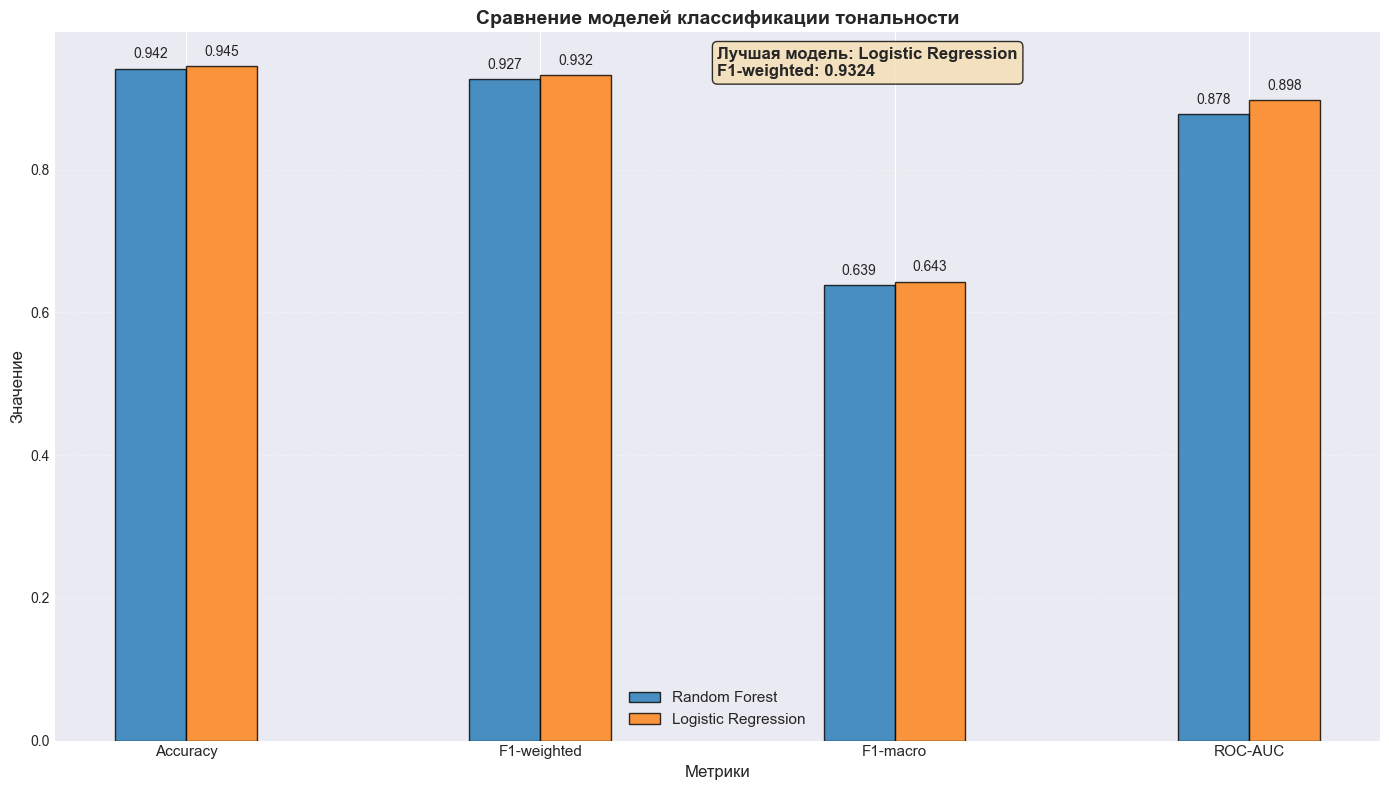

In [234]:
def plot_simple_comparison(rf_results, logreg_results):
    """Простая и понятная визуализация сравнения"""

    rf_model, rf_metrics, rf_pred, rf_proba = rf_results
    logreg_model, logreg_metrics, logreg_pred, logreg_proba = logreg_results

    # Основные метрики для сравнения
    metrics_names = ['Accuracy', 'F1-weighted', 'F1-macro', 'ROC-AUC']

    rf_values = [
        rf_metrics['accuracy'],
        rf_metrics['f1_weighted'],
        rf_metrics['f1_macro'],
        rf_metrics.get('roc_auc_ovr', 0)
    ]

    lr_values = [
        logreg_metrics['accuracy'],
        logreg_metrics['f1_weighted'],
        logreg_metrics['f1_macro'],
        logreg_metrics.get('roc_auc_ovr', 0)
    ]

    # Создаем график
    fig, ax = plt.subplots(figsize=(14, 8))

    x = np.arange(len(metrics_names))
    width = 0.2

    bars1 = ax.bar(x - width/2, rf_values, width,
                  label='Random Forest', color='#1f77b4', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, lr_values, width,
                  label='Logistic Regression', color='#ff7f0e', alpha=0.8, edgecolor='black')

    # Настройки
    ax.set_xlabel('Метрики', fontsize=12)
    ax.set_ylabel('Значение', fontsize=12)
    ax.set_title('Сравнение моделей классификации тональности', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Добавляем значения на столбцы
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # Выделяем лучшую модель по F1-weighted
    best_model = "Random Forest" if rf_metrics['f1_weighted'] > logreg_metrics['f1_weighted'] else "Logistic Regression"
    best_score = max(rf_metrics['f1_weighted'], logreg_metrics['f1_weighted'])

    # Добавляем аннотацию
    ax.text(0.5, 0.98, f'Лучшая модель: {best_model}\nF1-weighted: {best_score:.4f}',
           transform=ax.transAxes, fontsize=12, fontweight='bold',
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

# Используем упрощенную визуализацию
plot_simple_comparison(rf_results, logreg_results)

baseline_dataset

На этом заканчиваем EDA и работу с двумя моделями по определению тональности. Третий шаг саммаризации буду выполнять в py файле, чтобы был доступ к GPU.